In [1]:
import numpy as np
import pandas as pd
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from forge_class_instance3 import *
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from lifelines.utils import concordance_index
from sklearn.metrics import r2_score
from matplotlib import rcParams
# --- Setup Matplotlib for consistent font rendering ---
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

In [2]:
forge_model = FORGE.load_forge(path='/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/optuna_models/ERLOTINIB_EGFR_forgeModel_optuna100.pkl')
# forge_model.best_hyperparams

In [3]:
exp_data = pd.read_csv(forge_model.exp_path, header = 0, index_col = 0)
dep_data = pd.read_csv(forge_model.dep_path, header = 0, index_col = 0)
ic50_data = pd.read_csv(forge_model.ic50_path, header = 0, index_col = 0)
ic50_data = forge_model.ic50_data.T
exp_data.shape, dep_data.shape, ic50_data.shape

((1076, 16289), (1076, 17916), (1325, 187))

In [4]:
common_cellLines = list(set(exp_data.index) & set(dep_data.index) & set(ic50_data.index))
len(common_cellLines)

700

In [5]:
exp_data_subset = exp_data.loc[common_cellLines, forge_model.hcg_list].drop_duplicates(keep='first')
dep_target = dep_data.loc[common_cellLines, forge_model.target].dropna().drop_duplicates(keep='first')
drug_ic50 = ic50_data.loc[common_cellLines, forge_model.drug].dropna().drop_duplicates(keep='first')
exp_data_subset = exp_data.loc[dep_target.index, forge_model.hcg_list]
drug_ic50 = ic50_data.loc[dep_target.index, forge_model.drug]
exp_data_subset.shape, dep_target.shape, drug_ic50.shape

((699, 201), (699,), (699,))

In [6]:
exp_data_subset.head()

,MYBL1,UBL7-DT,AK5,REPS1,GGN,SQSTM1,NFIC,B3GNT3,SH2D3A,PERP,...,SYDE1,CRYBG2,FXYD3,RCC2-AS1,STARD8,ITGB4,HS3ST1,TMEM115,CRB3,EGFR
StrippedCellLineName,,,,,,,,,,,,,,,,,,,,,
SNU81,1.791079,1.318686,-2.085910,5.499631,-1.031462,9.406727,5.743244,4.879282,5.127288,8.019025,...,-1.589952,4.758293,6.175462,3.024222,-3.123385,8.280833,4.636766,4.903939,5.005627,6.902993
HEC251,3.241007,1.604535,-2.766487,5.653635,-0.238108,7.919362,5.235679,4.782779,5.261985,6.119365,...,3.521284,5.282523,0.459863,2.898666,-0.871980,9.541815,-0.568074,5.352587,4.653527,7.012053
HCC1954,3.834193,1.983663,-0.891330,5.415369,-1.748590,8.048484,5.866653,4.270557,4.772470,8.819875,...,2.801989,2.544831,8.013852,2.549090,1.524428,8.304667,1.841590,4.916643,3.628212,7.642202
KMRC20,5.138803,1.270085,2.920229,5.149037,-0.722433,11.174037,6.354382,-2.773059,-1.459399,6.737620,...,4.568062,-2.229917,-0.324913,1.399154,2.346771,1.817046,-0.983479,4.835539,3.860455,9.185338
UMUC1,2.853041,2.401401,-3.042415,4.862893,-1.457452,8.724659,4.153119,7.334967,6.361270,9.440884,...,2.927615,4.693720,8.758804,2.785137,-2.432361,10.193041,5.954468,5.356441,4.104656,8.509926


In [7]:
forge_model.exp_data = exp_data_subset
forge_model.dep_data = dep_target
forge_model.ic50_data = drug_ic50
forge_model.exp_data.shape, forge_model.dep_data.shape, forge_model.ic50_data.shape

((699, 201), (699,), (699,))

In [8]:
common_train_cellLines = list(set(forge_model.train_cellLines) & set(forge_model.exp_data.index))
common_test_cellLines = list(set(forge_model.test_cellLines) & set(forge_model.exp_data.index))

In [9]:
all_cellLines = common_train_cellLines[:]
all_cellLines.extend(common_test_cellLines)
len(all_cellLines)

686

In [10]:
G_train = forge_model.exp_data.loc[common_train_cellLines, :].to_numpy()
G_test  = forge_model.exp_data.loc[common_test_cellLines, :].to_numpy()

D_train = forge_model.dep_data.loc[common_train_cellLines].to_numpy().reshape(-1, 1)
D_test  = forge_model.dep_data.loc[common_test_cellLines].to_numpy().reshape(-1, 1)

I_train = forge_model.ic50_data.loc[common_train_cellLines].to_numpy().reshape(-1, 1)
I_test  = forge_model.ic50_data.loc[common_test_cellLines].to_numpy().reshape(-1, 1)

G_train.shape, D_train.shape, I_train.shape, G_test.shape, D_test.shape, I_test.shape

((549, 201), (549, 1), (549, 1), (137, 201), (137, 1), (137, 1))

In [11]:
## Construct weight matrices
dep_imp = forge_model.W @ forge_model.hD
ic50_imp = forge_model.W @ forge_model.hI
gene_imp_df = pd.DataFrame({'dep_imp': dep_imp.flatten(),
                            'ic50_imp': ic50_imp.flatten()},
                           index = forge_model.hcg_list)
gene_imp_df.head()

,dep_imp,ic50_imp
MYBL1,-0.000732,0.048128
UBL7-DT,-0.001444,-0.017670
AK5,0.005105,0.070035
REPS1,-0.000437,-0.068537
GGN,-0.005745,0.075533


In [12]:
full_exp_data = forge_model.exp_data.loc[all_cellLines, gene_imp_df.index]
full_exp_data_scaled = (full_exp_data - forge_model.mean_exp) / forge_model.std_exp
D_train, D_test = D_train - forge_model.mean_dep, D_test - forge_model.mean_dep
I_train, I_test = I_train - forge_model.mean_ic50, I_test - forge_model.mean_ic50
full_exp_data_scaled.shape, gene_imp_df.shape, D_train.shape, I_train.shape

((686, 201), (201, 2), (549, 1), (549, 1))

In [13]:
Z_matrix = full_exp_data_scaled.to_numpy() @ forge_model.W
Z_matrix.shape

(686, 25)

In [14]:
z_values_df = pd.DataFrame(Z_matrix, index=all_cellLines, columns=[f'dim{i}' for i in range(Z_matrix.shape[1])])
z_values_df['scaled_dep'] = D_train.flatten().tolist() + D_test.flatten().tolist()
z_values_df['scaled_ic50'] = I_train.flatten().tolist() + I_test.flatten().tolist()
z_values_df['pred_dep'] = (z_values_df[[f'dim{i}' for i in range(Z_matrix.shape[1])]].to_numpy() @ forge_model.hD).flatten() 
z_values_df['pred_ic50'] = (z_values_df[[f'dim{i}' for i in range(Z_matrix.shape[1])]].to_numpy() @ forge_model.hI).flatten()
z_values_df.head()

,dim0,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,...,dim19,dim20,dim21,dim22,dim23,dim24,scaled_dep,scaled_ic50,pred_dep,pred_ic50
SNU81,6.272538,-4.799966,4.698051,10.440197,5.187231,17.215158,1.600873,17.295939,-9.482857,4.193247,...,14.688576,11.980815,-6.443066,0.455137,3.305886,-5.460597,0.410524,-0.476315,0.207621,0.163579
HEC251,3.153316,-9.273485,-5.077915,10.606698,2.629205,7.607725,-6.261310,6.307446,-0.847220,-6.593734,...,1.704272,5.328385,-1.492421,0.352644,4.282234,4.820897,-0.224510,-1.101695,0.044341,-0.133039
HCC1954,-6.172708,0.944808,-2.077819,11.527102,18.983162,-2.607471,1.358946,4.107718,-2.057389,-11.264982,...,0.047475,0.081813,6.663098,3.429253,10.381804,-5.563725,0.526359,-1.443565,0.143835,-0.214706
KMRC20,-0.871039,6.063409,-6.754274,-0.527904,-13.032600,4.261869,33.119987,-14.447086,10.885169,-5.207297,...,-34.124219,-18.994334,9.943341,-10.714421,9.114694,-3.421322,0.176804,3.383875,-0.158377,1.938949
SW1990,-9.763471,-14.024934,-8.550620,14.195978,-14.617493,8.674591,1.792571,18.233859,-1.672886,-2.792961,...,-2.166947,11.544808,-11.336019,4.188647,6.993981,-5.160186,-0.020246,-0.029425,0.061849,0.873033


In [15]:
z_values_df['set'] = ['train' if cl in common_train_cellLines else 'test' for cl in z_values_df.index]
z_values_df['cell_line'] = z_values_df.index
z_values_df['benefit_score_raw'] = z_values_df['pred_dep'] - z_values_df['pred_ic50']
z_values_df['benefit_score_scaled'] = (z_values_df['benefit_score_raw'] - np.min(z_values_df['benefit_score_raw'])) / (np.max(z_values_df['benefit_score_raw']) - np.min(z_values_df['benefit_score_raw']))
z_values_df.head()

,dim0,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,...,dim23,dim24,scaled_dep,scaled_ic50,pred_dep,pred_ic50,set,cell_line,benefit_score_raw,benefit_score_scaled
SNU81,6.272538,-4.799966,4.698051,10.440197,5.187231,17.215158,1.600873,17.295939,-9.482857,4.193247,...,3.305886,-5.460597,0.410524,-0.476315,0.207621,0.163579,train,SNU81,0.044042,0.512244
HEC251,3.153316,-9.273485,-5.077915,10.606698,2.629205,7.607725,-6.261310,6.307446,-0.847220,-6.593734,...,4.282234,4.820897,-0.224510,-1.101695,0.044341,-0.133039,train,HEC251,0.177380,0.528494
HCC1954,-6.172708,0.944808,-2.077819,11.527102,18.983162,-2.607471,1.358946,4.107718,-2.057389,-11.264982,...,10.381804,-5.563725,0.526359,-1.443565,0.143835,-0.214706,train,HCC1954,0.358541,0.550574
KMRC20,-0.871039,6.063409,-6.754274,-0.527904,-13.032600,4.261869,33.119987,-14.447086,10.885169,-5.207297,...,9.114694,-3.421322,0.176804,3.383875,-0.158377,1.938949,train,KMRC20,-2.097326,0.251259
SW1990,-9.763471,-14.024934,-8.550620,14.195978,-14.617493,8.674591,1.792571,18.233859,-1.672886,-2.792961,...,6.993981,-5.160186,-0.020246,-0.029425,0.061849,0.873033,train,SW1990,-0.811184,0.408011


In [16]:
z_plot_df = z_values_df.drop(columns=[i for i in z_values_df.columns if not i.startswith('dim')])
z_plot_df = z_plot_df.sort_index()
z_values_df = z_values_df.loc[z_plot_df.index]
z_plot_df.head()

,dim0,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,...,dim15,dim16,dim17,dim18,dim19,dim20,dim21,dim22,dim23,dim24
22RV1,15.070516,2.110318,12.507632,-12.300128,12.533052,-7.315223,-3.968436,2.595230,-6.310228,12.178791,...,1.948762,0.735139,-8.655559,-7.666214,15.620449,-11.788260,-5.811699,8.377661,5.578766,-0.619777
2313287,15.126697,3.992169,-2.582105,-0.565921,15.970295,-1.398219,6.329730,18.360206,-0.696256,12.463213,...,12.032546,-4.725141,-8.709320,-22.985779,11.522511,8.739169,-11.315331,-1.653326,4.861144,-0.064647
253J,-25.841629,5.444899,-13.283011,-8.433864,4.070306,16.237590,9.521778,-15.382223,13.286316,-8.847282,...,-13.465101,-2.118349,-11.563794,-8.855336,-28.032172,19.118163,1.983315,13.735245,7.417003,11.142777
253JBV,-20.077915,4.045209,-18.874968,-7.184408,13.056097,9.383398,-2.857666,-5.584618,9.323419,-7.079888,...,-15.916146,1.974370,-3.203927,0.045072,-20.031467,27.402858,6.801945,20.246517,9.459428,5.950287
42MGBA,3.426879,-11.711808,20.527376,-6.841866,-22.475261,-4.091241,13.658918,-6.201748,21.617220,-4.023104,...,-0.584357,12.125294,-14.916517,23.043671,-15.675089,-9.347542,6.696579,12.134967,-9.231063,-4.732990


In [17]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
from matplotlib import rcParams
from dynamicTreeCut import cutreeHybrid
from matplotlib.patches import Patch

In [18]:
# === 3. Hierarchical Clustering and Annotation Color Mapping (on Combined Data) ===

print("Performing hierarchical clustering on the combined dataset...")

# --- Step 3a: Compute linkage matrices for the combined data ---
row_dist = pdist(z_plot_df.values, metric='euclidean')
row_link = linkage(row_dist, method='ward')
col_link = linkage(pdist(z_plot_df.T.values), method='ward')

# --- Step 3b: Run Dynamic Tree Cut to find clusters ---
cluster_result = cutreeHybrid(
    row_link, row_dist, deepSplit=4, minClusterSize=13)  # Set a min size
cluster_labels = pd.Series(
    cluster_result["labels"], index=z_plot_df.index, name="Cluster")
num_clusters = len(np.unique(cluster_labels[cluster_labels != 0]))
print(f"Dynamic Tree Cut found {num_clusters} clusters.")



Performing hierarchical clustering on the combined dataset...
..cutHeight not given, setting it to 906.7233274323804  ===>  99% of the (truncated) height range in dendro.
..done.
Dynamic Tree Cut found 30 clusters.


In [19]:
# %% [markdown]
# ### 1. Prepare Data: Assign Clusters and Merge Metadata

# %%
# 1. Ensure Cluster IDs are assigned to z_values_df (based on your previous cutreeHybrid result)
# Note: 'cluster_result' comes from the dynamicTreeCut step in your provided code
z_values_df['Cluster'] = pd.Series(cluster_result["labels"], index=z_values_df.index)

# Filter out unclustered cell lines (Cluster 0) if desired, or keep them.
# The image usually excludes '0' or treats it separately. Here we keep it for inspection.
df_plot_clusters = z_values_df.copy()



In [20]:
# 2. Load the Metadata
# Replace 'path/to/Model.csv' with your actual metadata file path
metadata_path = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Model_24_Q4.csv' 
metadata = pd.read_csv(metadata_path)

# 3. Merge Metadata
# We need to map the index of z_values_df (CellLineName) to the metadata.
# Try matching 'CellLineName' or 'StrippedCellLineName'. 
# Your z_values_df index seems to be stripped names or standard names (e.g., A431, HL60).

# Create a merge key in z_values_df
df_plot_clusters['merge_key'] = df_plot_clusters.index

# Attempt merge. We use 'left' to keep all cell lines in your analysis even if metadata is missing.
merged_df = df_plot_clusters.merge(
    metadata[['CellLineName', 'StrippedCellLineName', 'OncotreeLineage', 'OncotreePrimaryDisease']],
    left_on='merge_key', 
    right_on='StrippedCellLineName', # Try 'CellLineName' if Stripped doesn't match well
    how='left'
)

# Fill NaN lineages with "NA" or "Unknown"
merged_df['OncotreeLineage'] = merged_df['OncotreeLineage'].fillna('NA')

print("Merged shape:", merged_df.shape)
print("Unique Lineages found:", merged_df['OncotreeLineage'].unique())
merged_df.head()

Merged shape: (686, 39)
Unique Lineages found: ['Prostate' 'Esophagus/Stomach' 'Bladder/Urinary Tract' 'CNS/Brain'
 'Lymphoid' 'Kidney' 'Thyroid' 'Skin' 'Head and Neck'
 'Ovary/Fallopian Tube' 'Lung' 'Bone' 'Pleura' 'Myeloid' 'Pancreas'
 'Breast' 'Bowel' 'Cervix' 'Peripheral Nervous System' 'Uterus'
 'Soft Tissue' 'Liver' 'Vulva/Vagina' 'Biliary Tract' 'Testis'
 'Ampulla of Vater' 'Adrenal Gland']


,dim0,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,...,set,cell_line,benefit_score_raw,benefit_score_scaled,Cluster,merge_key,CellLineName,StrippedCellLineName,OncotreeLineage,OncotreePrimaryDisease
0,15.070516,2.110318,12.507632,-12.300128,12.533052,-7.315223,-3.968436,2.595230,-6.310228,12.178791,...,test,22RV1,-0.290027,0.471528,4,22RV1,22Rv1,22RV1,Prostate,Prostate Adenocarcinoma
1,15.126697,3.992169,-2.582105,-0.565921,15.970295,-1.398219,6.329730,18.360206,-0.696256,12.463213,...,train,2313287,0.710217,0.593435,4,2313287,23132/87,2313287,Esophagus/Stomach,Esophagogastric Adenocarcinoma
2,-25.841629,5.444899,-13.283011,-8.433864,4.070306,16.237590,9.521778,-15.382223,13.286316,-8.847282,...,train,253J,-0.348327,0.464423,7,253J,253J,253J,Bladder/Urinary Tract,Bladder Urothelial Carcinoma
3,-20.077915,4.045209,-18.874968,-7.184408,13.056097,9.383398,-2.857666,-5.584618,9.323419,-7.079888,...,train,253JBV,0.487096,0.566242,7,253JBV,253J-BV,253JBV,Bladder/Urinary Tract,Bladder Urothelial Carcinoma
4,3.426879,-11.711808,20.527376,-6.841866,-22.475261,-4.091241,13.658918,-6.201748,21.617220,-4.023104,...,test,42MGBA,-1.930768,0.271559,6,42MGBA,42-MG-BA,42MGBA,CNS/Brain,Diffuse Glioma


In [23]:
merged_df.to_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/revision_final/Suppl_data/Suppl_3a.csv", index=False)

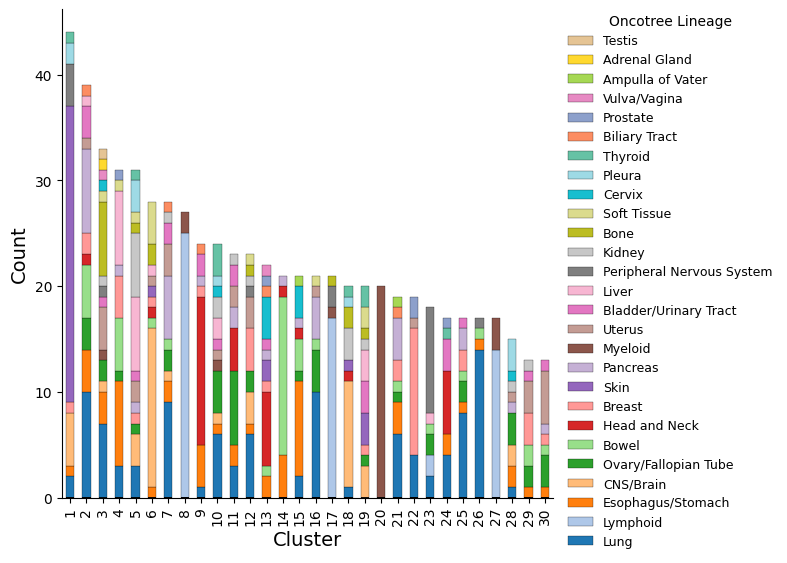

In [ ]:
# %% [markdown]
# ### 2. Generate Figure Panel a: Stacked Bar Chart of Lineages per Cluster

# %%
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare the counts data
# Group by Cluster and Lineage, then count
cluster_counts = merged_df.groupby(['Cluster', 'OncotreeLineage']).size().unstack(fill_value=0)

# Remove Cluster 0 (unassigned) if you want to match the paper figure exactly
if 0 in cluster_counts.index:
    cluster_counts = cluster_counts.drop(0)

# Sort columns (Lineages) alphabetically or by total frequency for better visualization
# sorting by frequency puts the most common tissues at the bottom/top
lineage_order = cluster_counts.sum().sort_values(ascending=False).index
cluster_counts = cluster_counts[lineage_order]

# 2. Define Colors (Attempting to match the diverse palette in the image)
# We need a large palette. 'tab20' is good, or we can concatenate palettes if >20 lineages.
unique_lineages = cluster_counts.columns
num_lineages = len(unique_lineages)

if num_lineages <= 20:
    colors = sns.color_palette("tab20", n_colors=num_lineages)
else:
    # Combine palettes for more colors
    colors = sns.color_palette("tab20", 20) + sns.color_palette("Set2", num_lineages - 20)

lineage_color_map = dict(zip(unique_lineages, colors))

# 3. Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Plot stacked bars
cluster_counts.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=[lineage_color_map[l] for l in cluster_counts.columns],
    width=0.5,
    edgecolor='black',
    linewidth=0.2
)

# 4. Formatting to match the provided image
#ax.set_title("a", loc='left', fontsize=20, fontweight='bold', pad=10) # The 'a' label
ax.set_ylabel("Count", fontsize=14)
ax.set_xlabel("Cluster", fontsize=14)

# Formatting X-axis tick labels
plt.xticks(rotation=90, fontsize=10)

# Remove top and right spines
sns.despine()

# 5. Custom Legend
# The image has a clean legend outside the plot.
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1], labels[::-1], # Reverse order to match stacking order
    title='Oncotree Lineage', 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0,
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.savefig('/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/Cluster_Lineage_Composition.pdf', dpi=300, bbox_inches='tight')
plt.show()